In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. Define Data Augmentation for Training and Normalization for Testing
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 2. Download and Load CIFAR-10 Dataset
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)

test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)

# Class names in CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Data loading complete! Training batches: {len(train_loader)}, Testing batches: {len(test_loader)}")

100%|██████████| 170M/170M [00:04<00:00, 35.2MB/s]


Data loading complete! Training batches: 782, Testing batches: 157


In [2]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Check if GPU is available for acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Define the CNN Model with Dropout
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Block 1: Input (3 channels) -> Output (32 channels)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # Reduces dimensions by half

        # Block 2: Input (64 channels) -> Output (128 channels)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Dropout layer for regularization (drops 30% of activations)
        self.dropout = nn.Dropout(0.3)

        # Fully Connected Layers (CIFAR-10 images become 8x8 after two poolings)
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10) # 10 output classes

    def forward(self, x):
        # Apply conv, activation, and pooling
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(x) # Regularization after block 1

        x = self.pool2(F.relu(self.conv3(x)))
        x = self.dropout(x) # Regularization after block 2

        # Flatten the feature maps for the dense layers
        x = x.view(-1, 128 * 8 * 8)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Initialize model and push to device
model = SimpleCNN().to(device)

# 2. Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("CNN Architecture successfully created and compiled!")

Using device: cuda
CNN Architecture successfully created and compiled!


In [3]:
import time

# Lists to track metrics for plotting in the next step
epoch_losses = []
epoch_accuracies = []

epochs = 10
print("Starting training process...\n")

for epoch in range(epochs):
    start_time = time.time()
    model.train()  # Set model to training mode (activates dropout)
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero out the parameter gradients
        optimizer.zero_grad()

        # Forward pass + Backward pass + Optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    # Calculate average loss for this epoch
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_losses.append(epoch_loss)

    # Evaluate accuracy on test data for this epoch
    model.eval()  # Set model to evaluation mode (deactivates dropout)
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_acc = (correct / total) * 100
    epoch_accuracies.append(epoch_acc)

    elapsed_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Test Acc: {epoch_acc:.2f}% | Time: {elapsed_time:.2f}s")

print("\nTraining completed successfully!")

Starting training process...

Epoch [1/10] | Loss: 1.5733 | Test Acc: 58.39% | Time: 25.41s
Epoch [2/10] | Loss: 1.1757 | Test Acc: 67.97% | Time: 24.24s
Epoch [3/10] | Loss: 1.0305 | Test Acc: 70.94% | Time: 25.37s
Epoch [4/10] | Loss: 0.9610 | Test Acc: 72.11% | Time: 32.29s
Epoch [5/10] | Loss: 0.9094 | Test Acc: 74.18% | Time: 24.70s
Epoch [6/10] | Loss: 0.8731 | Test Acc: 74.19% | Time: 24.67s
Epoch [7/10] | Loss: 0.8431 | Test Acc: 75.72% | Time: 24.88s
Epoch [8/10] | Loss: 0.8301 | Test Acc: 75.43% | Time: 25.07s
Epoch [9/10] | Loss: 0.8026 | Test Acc: 77.08% | Time: 24.85s
Epoch [10/10] | Loss: 0.7894 | Test Acc: 77.63% | Time: 24.59s

Training completed successfully!


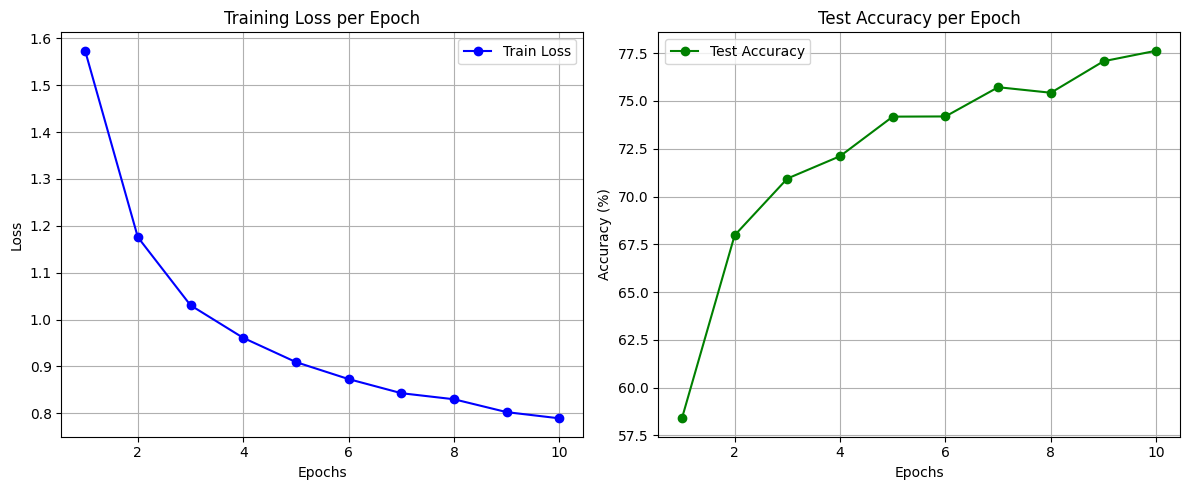

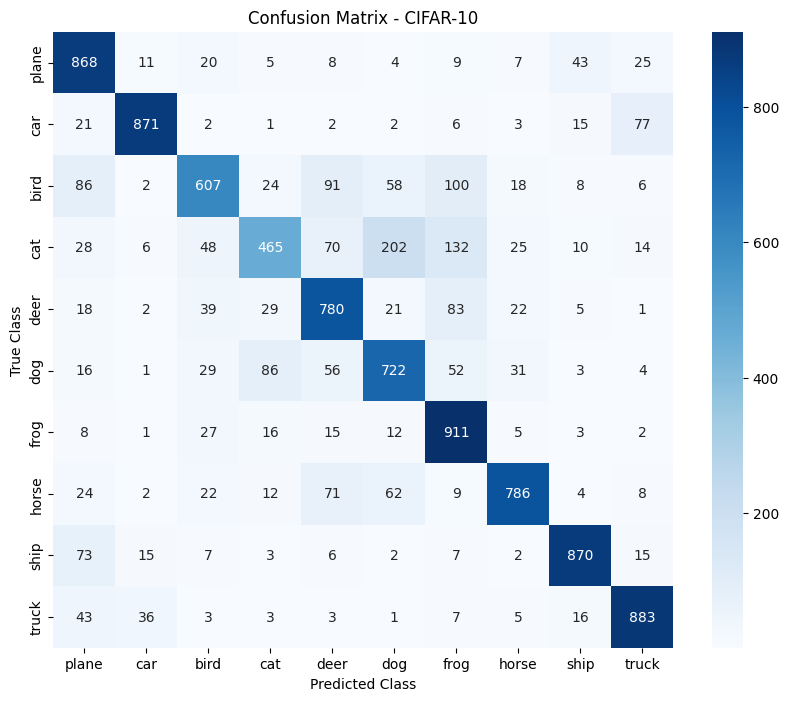

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Plot the Training Loss & Testing Accuracy Curves
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', color='b', label='Train Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(epoch_accuracies) + 1), epoch_accuracies, marker='o', color='g', label='Test Accuracy')
plt.title('Test Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# 2. Gather All Predictions for the Confusion Matrix
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# 3. Compute and Plot the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - CIFAR-10')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()